In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, brier_score_loss,
                             precision_recall_curve, roc_curve,
                             average_precision_score)

# Calibration curve helpers
from sklearn.calibration import calibration_curve
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 20000

In [3]:
print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])
np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

feature_cols = ['Age', 'year', 'Code.Profession', 'Diagnostic.means',
                'Extension', 'Raca.Color']
df_feat = df[feature_cols + ['target']].copy()
cat_cols = ['Diagnostic.means', 'Extension', 'Raca.Color']
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    mc = non_null.value_counts().index[0]
    def encode(x):
        if pd.isna(x): return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([mc])[0]
    df_feat[col] = df_feat[col].apply(encode)

X = df_feat[feature_cols].astype(float).values
y = df_feat['target'].values
n_pos = (y == 1).sum()
n_neg = (y == 0).sum()
print(f"    总样本: {len(X):,}  VIVO: {n_pos:,} ({n_pos/len(X)*100:.2f}%)")

# 固定划分
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
print(f"    训练集: {len(X_tr):,}  测试集: {len(X_te):,}")

# 预处理器
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_tr_imp = imputer.fit_transform(X_tr)
X_te_imp = imputer.transform(X_te)
X_tr_final = scaler.fit_transform(X_tr_imp)
X_te_final = scaler.transform(X_te_imp)


[0] 加载数据...
    总样本: 20,000  VIVO: 8,230 (41.15%)
    训练集: 14,000  测试集: 6,000


# 第一部分: 校准分析

In [4]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
}


import xgboost as xgb
models['XGBoost'] = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),
    random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss',
    use_label_encoder=False)



from sklearn.neighbors import KNeighborsClassifier
models['KNN (k=15)'] = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)


In [5]:
calibration_data = {}

for name, model in models.items():
    if name == 'KNN (k=15)':
        model.fit(X_tr_final, y_tr)
        y_prob = model.predict_proba(X_te_final)[:, 1]
    else:
        model.fit(X_tr_imp, y_tr)
        y_prob = model.predict_proba(X_te_imp)[:, 1]

    # AUC
    auc = roc_auc_score(y_te, y_prob)

    # Brier Score
    brier = brier_score_loss(y_te, y_prob)

    # Calibration Curve (10 bins)
    prob_true, prob_pred = calibration_curve(y_te, y_prob, n_bins=10, strategy='uniform')

    calibration_data[name] = {
        'auc': auc, 'brier': brier,
        'prob_true': prob_true, 'prob_pred': prob_pred, 'y_prob': y_prob
    }

    print(f"\n  [{name}]")
    print(f"    AUC  = {auc:.4f}")
    print(f"    Brier= {brier:.4f}")


  [Logistic Regression]
    AUC  = 0.8944
    Brier= 0.1307

  [Random Forest]
    AUC  = 0.9162
    Brier= 0.1164

  [XGBoost]
    AUC  = 0.9168
    Brier= 0.1153

  [KNN (k=15)]
    AUC  = 0.9048
    Brier= 0.1216



  [图] 14a_calibration_curves.png → 校准曲线已保存


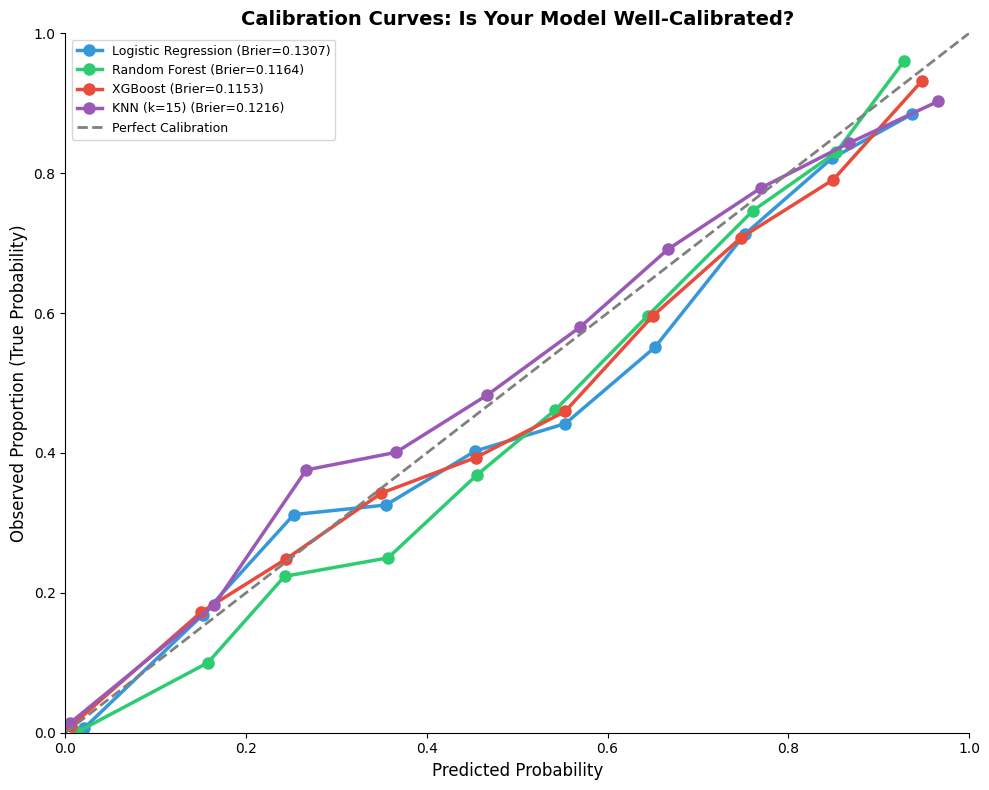

In [6]:

# --- 图 1: Calibration Curve ---
fig, ax = plt.subplots(figsize=(10, 8))
colors_cc = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for idx, (name, data) in enumerate(calibration_data.items()):
    ax.plot(data['prob_pred'], data['prob_true'], 'o-',
            color=colors_cc[idx % len(colors_cc)], linewidth=2.5,
            markersize=8, label=f"{name} (Brier={data['brier']:.4f})")

ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=2, label='Perfect Calibration')
ax.set_xlabel('Predicted Probability', fontsize=12)
ax.set_ylabel('Observed Proportion (True Probability)', fontsize=12)
ax.set_title('Calibration Curves: Is Your Model Well-Calibrated?',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14a_calibration_curves.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 14a_calibration_curves.png → 校准曲线已保存")

In [7]:
print("\n  --- Hosmer-Lemeshow Goodness-of-Fit Test ---")

def hosmer_lemeshow_test(y_true, y_prob, n_groups=10):
    """
    Hosmer-Lemeshow 检验
    H0: 模型校准良好 (预测概率 = 实际比例)
    如果 p < 0.05 → 拒绝 H0 → 校准不良
    """
    from scipy.stats import chi2

    df_hl = pd.DataFrame({'y': y_true, 'prob': y_prob})
    df_hl['decile'] = pd.qcut(df_hl['prob'].rank(method='first'),
                               q=n_groups, labels=False)

    obs_pos = df_hl.groupby('decile')['y'].sum().values
    obs_neg = df_hl.groupby('decile')['y'].count().values - obs_pos
    exp_pos = df_hl.groupby('decile')['prob'].sum().values
    exp_neg = df_hl.groupby('decile')['prob'].count().values - exp_pos

    # 防止除零
    exp_pos = np.maximum(exp_pos, 1e-10)
    exp_neg = np.maximum(exp_neg, 1e-10)

    chi2_stat = np.sum((obs_pos - exp_pos)**2 / exp_pos +
                       (obs_neg - exp_neg)**2 / exp_neg)
    p_value = 1 - chi2.cdf(chi2_stat, n_groups - 2)

    return chi2_stat, p_value

hl_results = {}
for name, data in calibration_data.items():
    chi2, p = hosmer_lemeshow_test(y_te, data['y_prob'])
    hl_results[name] = {'chi2': chi2, 'p': p}
    print(f"  {name:<25}  χ²={chi2:.2f}  p={p:.4f}  {'良好' if p > 0.05 else '不良'}")


  --- Hosmer-Lemeshow Goodness-of-Fit Test ---
  Logistic Regression        χ²=111.46  p=0.0000  不良
  Random Forest              χ²=74.64  p=0.0000  不良
  XGBoost                    χ²=54.74  p=0.0000  不良
  KNN (k=15)                 χ²=360000000083.32  p=0.0000  不良


In [8]:
print("\n  --- Brier Score 分解 (Murphy分解) ---")

def brier_decomposition(y_true, y_prob):
    """Murphy分解: Brier = REFINEMENT + CALIBRATION + UNCERTAINTY"""
    # 不确定性 = ȳ(1-ȳ)
    y_bar = y_true.mean()
    uncertainty = y_bar * (1 - y_bar)

    # 校准度: 分组到 10 个 bin
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_prob, bin_edges) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)

    calibration = 0
    refinement = 0
    for bin_i in range(n_bins):
        mask = bin_indices == bin_i
        n_k = mask.sum()
        if n_k == 0:
            continue
        o_k = y_true[mask].mean()
        r_k = y_prob[mask].mean()
        calibration += n_k / len(y_true) * (o_k - r_k)**2
        refinement += n_k / len(y_true) * o_k * (1 - o_k)

    return refinement, calibration, uncertainty

print(f"  {'Model':<25} {'Brier':>8} {'鉴别力':>8} {'校准度':>8} {'不确定性':>10}")
print(f"  {'-'*25} {'-'*8} {'-'*8} {'-'*8} {'-'*10}")
for name, data in calibration_data.items():
    ref, cal, unc = brier_decomposition(y_te, data['y_prob'])
    brier = brier_score_loss(y_te, data['y_prob'])
    print(f"  {name:<25} {brier:.4f}   {ref:.4f}   {cal:.4f}   {unc:.4f}")



  --- Brier Score 分解 (Murphy分解) ---
  Model                        Brier      鉴别力      校准度       不确定性
  ------------------------- -------- -------- -------- ----------
  Logistic Regression       0.1307   0.1283   0.0026   0.2422
  Random Forest             0.1164   0.1153   0.0019   0.2422
  XGBoost                   0.1153   0.1144   0.0016   0.2422
  KNN (k=15)                0.1216   0.1216   0.0010   0.2422



  [图] 14b_auc_vs_brier.png → AUC vs Brier 已保存


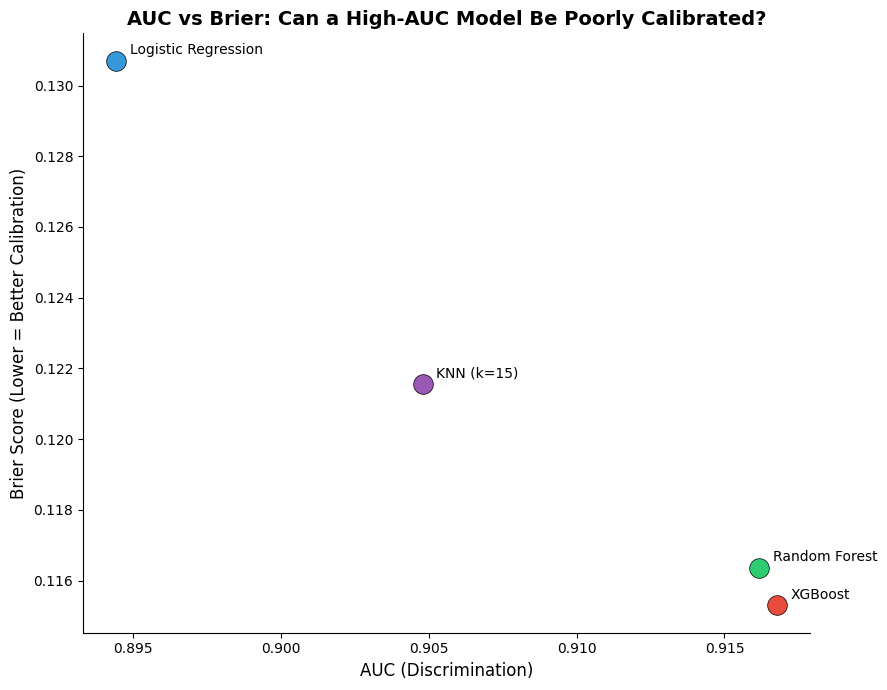

In [9]:
# --- 图 2: AUC vs Brier 散点 ---
fig, ax = plt.subplots(figsize=(9, 7))
for name, data in calibration_data.items():
    ax.scatter(data['auc'], data['brier'], s=200,
               color=colors_cc[list(calibration_data.keys()).index(name)],
               edgecolors='black', linewidths=0.5, zorder=5)
    ax.annotate(name, (data['auc'], data['brier']),
                textcoords='offset points', xytext=(10, 5), fontsize=10)

ax.set_xlabel('AUC (Discrimination)', fontsize=12)
ax.set_ylabel('Brier Score (Lower = Better Calibration)', fontsize=12)
ax.set_title('AUC vs Brier: Can a High-AUC Model Be Poorly Calibrated?',
             fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14b_auc_vs_brier.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 14b_auc_vs_brier.png → AUC vs Brier 已保存")


  [图] 14c_hl_test.png → Hosmer-Lemeshow 检验已保存


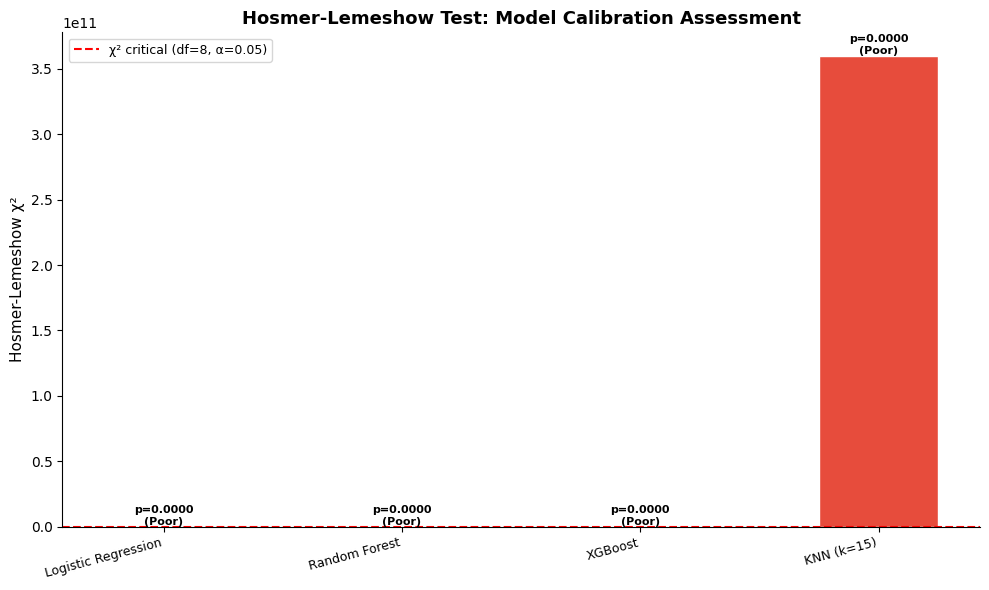

In [10]:
# --- 图 3: 校准度直方图 ---
fig, ax = plt.subplots(figsize=(10, 6))
names_hl = list(hl_results.keys())
chi2s = [hl_results[n]['chi2'] for n in names_hl]
ps = [hl_results[n]['p'] for n in names_hl]

colors_hl = ['#2ecc71' if p > 0.05 else '#e74c3c' for p in ps]
bars = ax.bar(range(len(names_hl)), chi2s, color=colors_hl, edgecolor='white', width=0.5)
ax.axhline(y=15.507, color='red', linestyle='--', linewidth=1.5,
           label='χ² critical (df=8, α=0.05)')
ax.set_xticks(range(len(names_hl)))
ax.set_xticklabels(names_hl, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Hosmer-Lemeshow χ²', fontsize=11)
ax.set_title('Hosmer-Lemeshow Test: Model Calibration Assessment',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar, p in zip(bars, ps):
    status = 'Good' if p > 0.05 else 'Poor'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'p={p:.4f}\n({status})', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14c_hl_test.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 14c_hl_test.png → Hosmer-Lemeshow 检验已保存")

# 第二部分: 决策曲线分析 (DCA)

In [11]:
def dca_net_benefit(y_true, y_prob, thresholds):
    """
    计算 DCA 的净获益 (Net Benefit)
    NB = TP/N - FP/N × (pt / (1-pt))

    参数:
      y_true: 真实标签 (1=正类)
      y_prob: 预测概率
      thresholds: 风险阈值数组

    返回:
      net_benefits: 各阈值下的净获益
    """
    N = len(y_true)
    net_benefits = []

    for pt in thresholds:
        # 模型: 概率 > pt 则干预
        y_pred = (y_prob >= pt).astype(int)

        TP = ((y_pred == 1) & (y_true == 1)).sum()
        FP = ((y_pred == 1) & (y_true == 0)).sum()

        # NB = TP/N - FP/N × pt/(1-pt)
        if pt == 0 or pt == 1:
            nb = 0
        else:
            nb = TP / N - FP / N * (pt / (1 - pt))
        net_benefits.append(nb)

    return np.array(net_benefits)


def dca_treat_all(y_true, thresholds):
    """所有患者都干预的净获益"""
    N = len(y_true)
    n_pos = (y_true == 1).sum()
    net_benefits = []
    for pt in thresholds:
        # Treat All: TP = 所有正类, FP = 所有负类
        if pt == 0 or pt == 1:
            nb = 0
        else:
            TP = n_pos
            FP = N - n_pos
            nb = TP / N - FP / N * (pt / (1 - pt))
        net_benefits.append(nb)
    return np.array(net_benefits)


def dca_treat_none(y_true, thresholds):
    """所有患者都不干预的净获益 = 0"""
    return np.zeros(len(thresholds))

In [12]:
thresholds = np.linspace(0.01, 0.99, 99)

dca_results = {}

for name, data in calibration_data.items():
    dca_results[name] = dca_net_benefit(y_te, data['y_prob'], thresholds)

nb_treat_all = dca_treat_all(y_te, thresholds)
nb_treat_none = dca_treat_none(y_te, thresholds)


  [图] 14d_dca_curves.png → DCA 曲线已保存


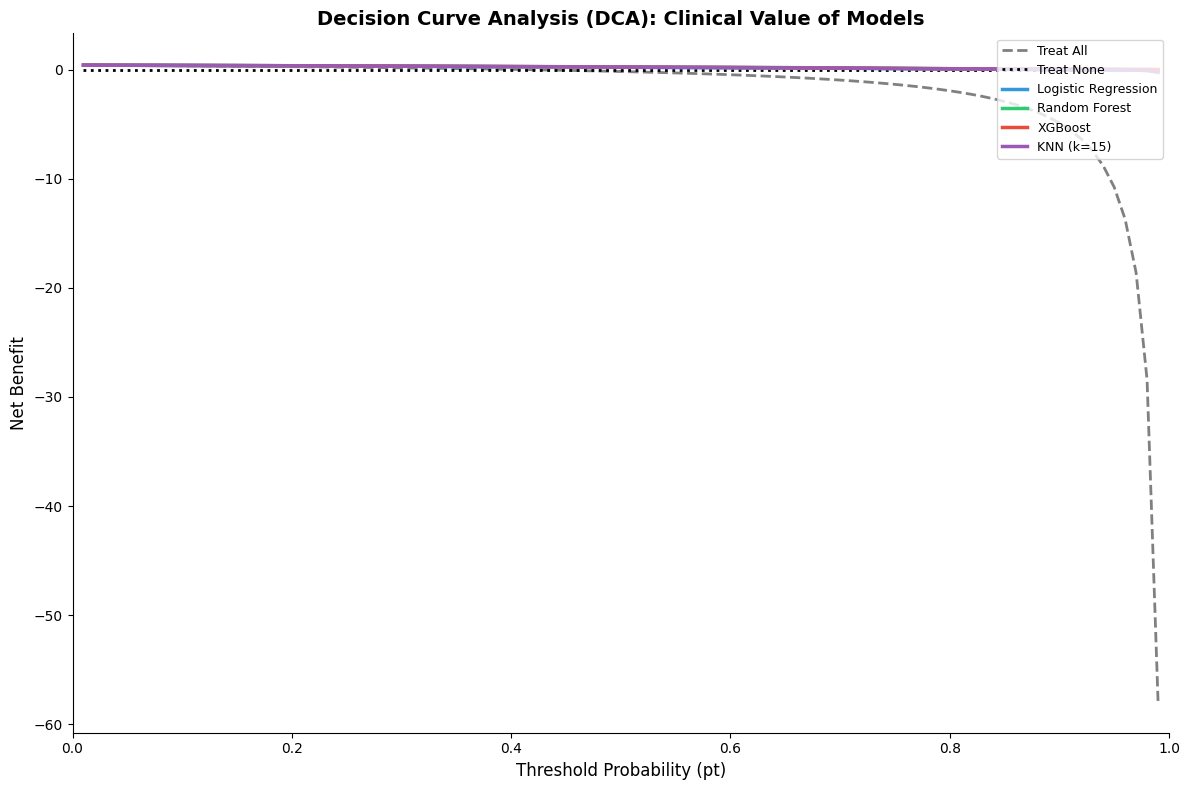

In [13]:
# --- 图 4: DCA 曲线 ---
fig, ax = plt.subplots(figsize=(12, 8))

# Treat All
ax.plot(thresholds, nb_treat_all, '--', color='gray', linewidth=2,
        label='Treat All')
# Treat None
ax.plot(thresholds, nb_treat_none, ':', color='black', linewidth=2,
        label='Treat None')

# 模型
for idx, (name, nb) in enumerate(dca_results.items()):
    ax.plot(thresholds, nb, '-', color=colors_cc[idx % len(colors_cc)],
            linewidth=2.5, label=f'{name}')

ax.set_xlabel('Threshold Probability (pt)', fontsize=12)
ax.set_ylabel('Net Benefit', fontsize=12)
ax.set_title('Decision Curve Analysis (DCA): Clinical Value of Models',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_xlim([0, 1])
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14d_dca_curves.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 14d_dca_curves.png → DCA 曲线已保存")

In [14]:
# --- 寻找临床获益范围 ---
print("\n  --- 临床获益范围分析 ---")
for name, nb in dca_results.items():
    # 找到模型优于 Treat All 和 Treat None 的阈值范围
    better_than_none = nb > nb_treat_none
    better_than_all = nb > nb_treat_all
    beneficial = better_than_none & better_than_all

    if beneficial.any():
        idx_beneficial = np.where(beneficial)[0]
        pt_start = thresholds[idx_beneficial[0]]
        pt_end = thresholds[idx_beneficial[-1]]
        max_nb = nb.max()
        max_nb_pt = thresholds[nb.argmax()]
        print(f"  {name:<25}")
        print(f"    获益范围: pt ∈ [{pt_start:.2f}, {pt_end:.2f}]")
        print(f"    最大净获益: {max_nb:.4f} (pt = {max_nb_pt:.2f})")
    else:
        print(f"  {name:<25} 未发现临床获益范围")


  --- 临床获益范围分析 ---
  Logistic Regression      
    获益范围: pt ∈ [0.01, 0.87]
    最大净获益: 0.4069 (pt = 0.01)
  Random Forest            
    获益范围: pt ∈ [0.01, 0.97]
    最大净获益: 0.4072 (pt = 0.01)
  XGBoost                  
    获益范围: pt ∈ [0.01, 0.98]
    最大净获益: 0.4088 (pt = 0.01)
  KNN (k=15)               
    获益范围: pt ∈ [0.01, 0.94]
    最大净获益: 0.4073 (pt = 0.01)


  [图] 14e_dca_thresholds.png → DCA 阈值对比已保存


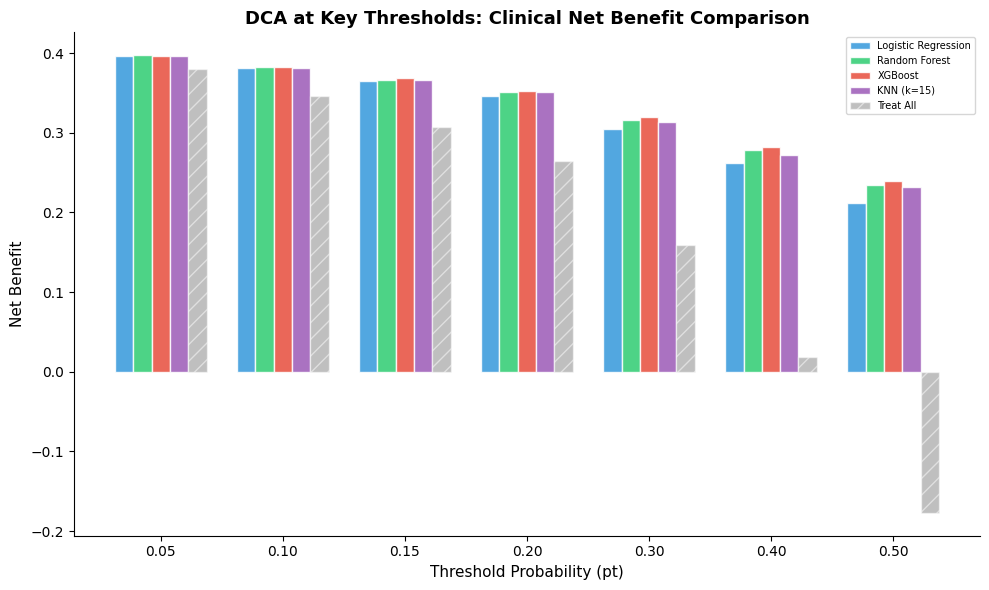

In [15]:
# --- 图 5: 各模型 DCA 对比 (Selected thresholds) ---
fig, ax = plt.subplots(figsize=(10, 6))
selected_thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
x_labels = [f'{pt:.2f}' for pt in selected_thresholds]
x_pos = np.arange(len(x_labels))
width_dca = 0.15

for idx, (name, data) in enumerate(calibration_data.items()):
    nb_vals = []
    for pt in selected_thresholds:
        # Recalculate y_pred at this threshold
        y_pred = (data['y_prob'] >= pt).astype(int)
        TP = ((y_pred == 1) & (y_te == 1)).sum()
        FP = ((y_pred == 1) & (y_te == 0)).sum()
        N = len(y_te)
        if pt <= 0 or pt >= 1:
            nb_vals.append(0)
        else:
            nb_vals.append(TP/N - FP/N * (pt/(1-pt)))
    ax.bar(x_pos + (idx - 2) * width_dca, nb_vals, width_dca,
           color=colors_cc[idx % len(colors_cc)],
           edgecolor='white', label=name, alpha=0.85)

# Add Treat All
nb_all_vals = []
for pt in selected_thresholds:
    N = len(y_te); n_p = (y_te == 1).sum()
    nb_all_vals.append(n_p/N - (N-n_p)/N * (pt/(1-pt)) if 0 < pt < 1 else 0)
ax.bar(x_pos + (len(calibration_data) - 2) * width_dca, nb_all_vals, width_dca,
       color='gray', edgecolor='white', label='Treat All', alpha=0.5, hatch='//')

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Threshold Probability (pt)', fontsize=11)
ax.set_ylabel('Net Benefit', fontsize=11)
ax.set_title('DCA at Key Thresholds: Clinical Net Benefit Comparison',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=7, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14e_dca_thresholds.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 14e_dca_thresholds.png → DCA 阈值对比已保存")